In [2]:
import nibabel as nib
import numpy as np

import matplotlib.pyplot as plt

In [3]:
def get_dice(pred, gt):
    # num is the total number of classes, include the background
    dice = 2*np.sum(pred*gt)/(np.sum(pred+gt))
            
    return dice

In [4]:
#128 sized data
# load() function creates a NiBabel image object from a NIfTI file.
# load the target mask, and the corresponding predicted mask
slice_num     = 60
pred_mask       = nib.load('/Users/yamunasn/RR_AFNI_VNET/CNNouts/wt_out_128/pro128_twelve_point5/ch01-fore_ep-035_val_sub-0013.nii.gz')
targ_mask       = nib.load('target_095_val_0013.nii.gz')
targ_mask_edt   = nib.load('target_095_val_0013_EDT.nii.gz')
targ_edt_rim        = nib.load('test128_rim.nii.gz')
targ_edt_core       = nib.load('test128_core.nii.gz')

In [5]:
pred_mask_data = pred_mask.get_fdata()
print('pred_mask_data shape = ',(pred_mask_data.shape))
pred_mask_data_slice = pred_mask_data[slice_num, :, :]
print('pred_mask_data_slice shape = ',pred_mask_data_slice.shape)

#plt.imshow(pred_mask_data_slice, cmap='gray')
#plt.title('pred_mask_data_slice')
#plt.show()
#print(mid_slice_orig.max())


pred_mask_data shape =  (128, 128, 128)
pred_mask_data_slice shape =  (128, 128)


In [6]:
targ_mask_data = targ_mask.get_fdata()
print('targ_mask_data shape   = ',(targ_mask_data.shape))
targ_mask_data_slice = targ_mask_data[slice_num, :, :]
print('targ_mask_data_slice shape = ',targ_mask_data_slice.shape)

#plt.imshow(targ_mask_data_slice, cmap='gray')
#plt.title('targ_mask_data_slice')
#plt.show()


targ_mask_data shape   =  (128, 128, 128)
targ_mask_data_slice shape =  (128, 128)


In [7]:
targ_mask_edt_data = targ_mask_edt.get_fdata()
print('targ_mask_edt_data shape = ',(targ_mask_edt_data.shape))
targ_mask_edt_data_slice = targ_mask_edt_data[slice_num, :, :]
print('targ_mask_edt_data_slice shape = ',targ_mask_edt_data_slice.shape)

targ_mask_edt_data shape =  (128, 128, 128)
targ_mask_edt_data_slice shape =  (128, 128)


targ_edt_rim_data shape =  (128, 128, 128)
targ_edt_rim_data_slice shape =  (128, 128)


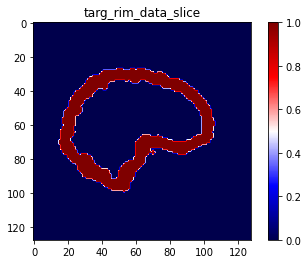

In [8]:
targ_edt_rim_data = targ_edt_rim.get_fdata()
print('targ_edt_rim_data shape = ',(targ_edt_rim_data.shape))
targ_edt_rim_data_slice = targ_edt_rim_data[slice_num, :, :]
print('targ_edt_rim_data_slice shape = ',targ_edt_rim_data_slice.shape)

plt.imshow(targ_edt_rim_data_slice, cmap='seismic')
plt.title('targ_rim_data_slice')
plt.colorbar()
plt.show()

targ_edt_core_data shape =  (128, 128, 128)
targ_edt_core_data_slice shape =  (128, 128)


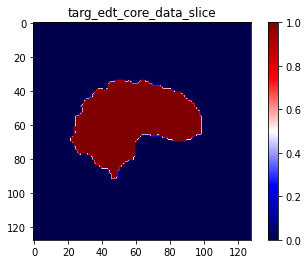

In [9]:
targ_edt_core_data = targ_edt_core.get_fdata()
print('targ_edt_core_data shape = ',(targ_edt_core_data.shape))
targ_edt_core_data_slice = targ_edt_core_data[slice_num, :, :]
print('targ_edt_core_data_slice shape = ',targ_edt_core_data_slice.shape)

plt.imshow(targ_edt_core_data_slice, cmap='seismic')
plt.title('targ_edt_core_data_slice')
plt.colorbar()
plt.show()

<div>
<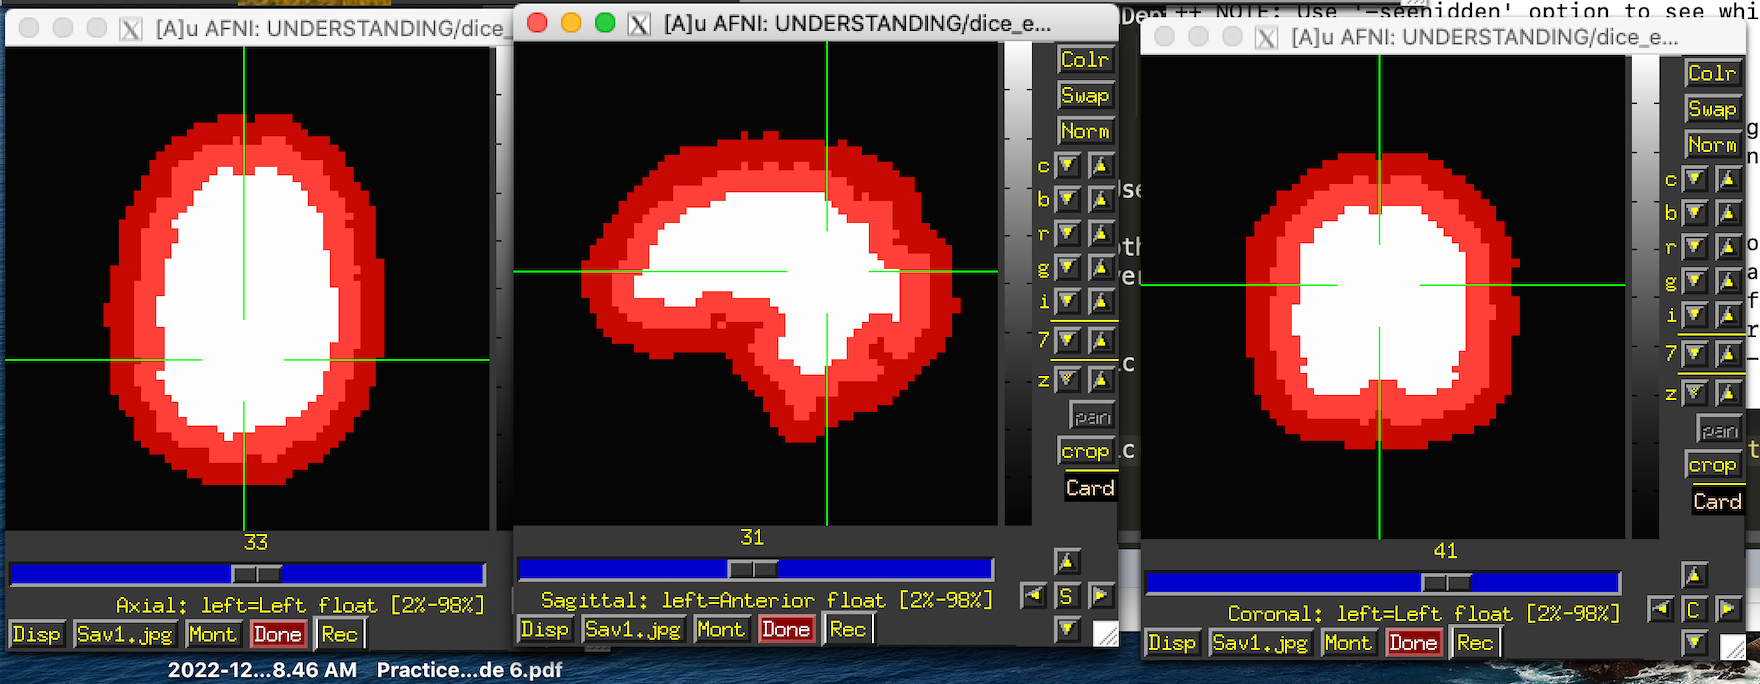>
</div>

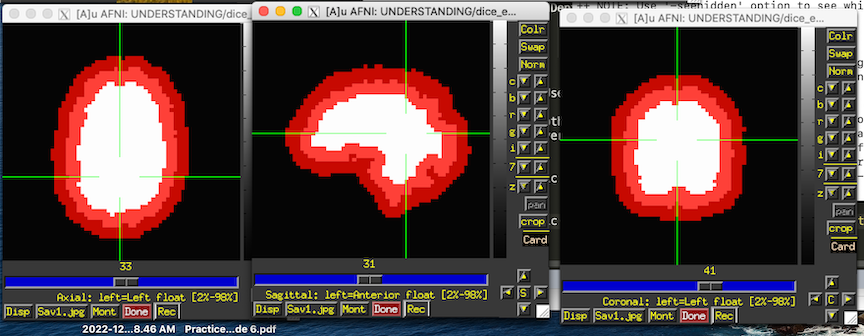

unique values of targ_rim_data_slice =  [0 1]
pred_rim shape =  (128, 128)


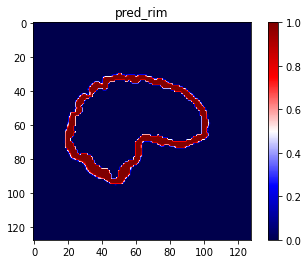

In [10]:
# scoop the core #pred_rim = (pred*rim)
#target_rim = (targ*rim)
targ_edt_rim_data_slice = (targ_edt_rim_data_slice > 0.5).astype(np.int_)  
print('unique values of targ_rim_data_slice = ', np.unique(targ_edt_rim_data_slice))
pred_rim = pred_mask_data_slice * targ_edt_rim_data_slice
targ_rim = targ_mask_data_slice * targ_edt_rim_data_slice
print('pred_rim shape = ',pred_rim.shape)
plt.imshow(pred_rim, cmap='seismic')
plt.title('pred_rim')
plt.colorbar()
plt.show()


targ_rim shape =  (128, 128)


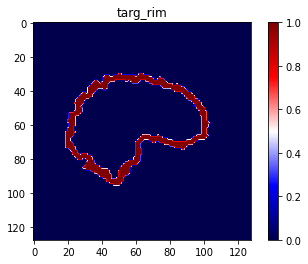

In [11]:
print('targ_rim shape = ',targ_rim.shape)
plt.imshow(targ_rim, cmap='seismic')
plt.title('targ_rim')
plt.colorbar()
plt.show()

In [16]:

dice_rim = get_dice(pred_rim,targ_rim)
print('dice_rim =',dice_rim)

dice_rim = 0.9327633547037736


pred_core shape =  (128, 128)


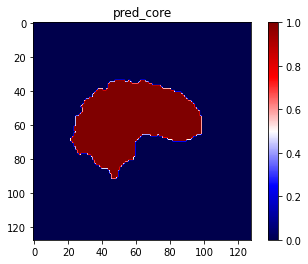

In [72]:
# remove the boundary # calculate dice_core
targ_edt_core_data_slice = (targ_edt_core_data_slice > 0.5).astype(np.int_) 
pred_core = pred_mask_data_slice * targ_edt_core_data_slice
targ_core = targ_mask_data_slice * targ_edt_core_data_slice
print('pred_core shape = ',pred_rim.shape)
plt.imshow(pred_core, cmap='seismic')
plt.title('pred_core')
plt.colorbar()
plt.show()

In [73]:
dice_core = get_dice(pred_core,targ_core)
print('dice_core =',dice_core)

dice_core = 1.0
